In [ ]:
import numpy as np
import time 
import matplotlib.pyplot as plt

In [182]:
n = 10 ** 7
v = np.float32(45.53125)
arr = [v] * n

# Sumowanie naiwne

In [183]:
def naive_sum():
    result = np.float32(0)

    for i in range(n):
        result += arr[i]

    return result

In [184]:
result = naive_sum()
expected = n * v

absolute_error = np.abs(expected - result)
relative_error = ((expected - result) / expected) * 100

print("Naive summing")
print(f"result={result}, absolute_error={absolute_error}, relative_error={relative_error}%")

Naive summing
result=406408416.0, absolute_error=48904096.0, relative_error=10.740776062011719%


In [185]:
def error_report():
    abs_errors = []
    rel_errors = []

    result = np.float32(0)

    for i in range(n):
        result += arr[i]

        if i % 25000 == 0:
            expected = (i + 1) * v
            abs_errors.append(np.abs(expected - result))
            rel_errors.append(((expected - result) / expected) * 100)

    return result, abs_errors, rel_errors

In [186]:
result, abs_errors, rel_errors = error_report()

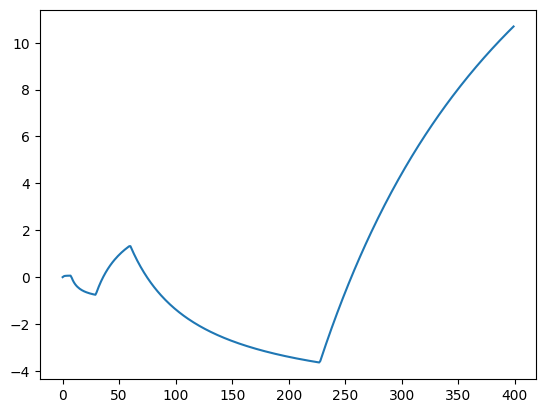

In [187]:
plt.plot(list(range(len(rel_errors))), rel_errors)

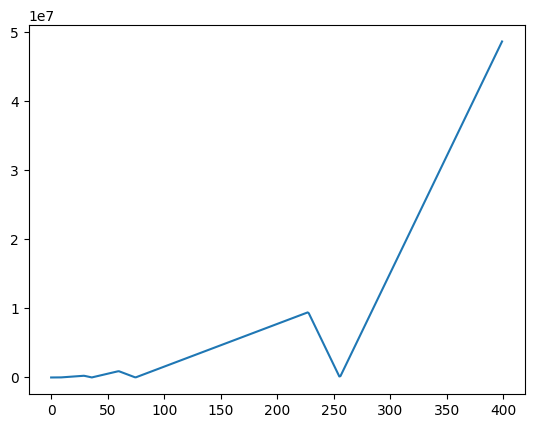

In [188]:
plt.plot(list(range(len(abs_errors))), abs_errors)

# Sumowanie rekurencyjne

In [189]:
def recursive_sum(arr: list[np.float32], l: int, r: int):
    if l == r:
        return arr[l]

    mid = (l + r) // 2 
    return recursive_sum(arr, l, mid) + recursive_sum(arr, mid + 1, r)

In [190]:
result = recursive_sum(arr, 0, len(arr) - 1)

absolute_error = np.abs(expected - result)
relative_error = ((expected - result) / expected) * 100

print("Recursive summing")
print(f"result={result}, absolute_error={absolute_error}, relative_error={relative_error}%")

Recursive summing
result=455312512.0, absolute_error=0.0, relative_error=0.0%


# Porównanie czasów działania

In [191]:
start = time.perf_counter()
naive_sum()
end = time.perf_counter()

naive_time = end - start

print("Naive summing time")
print(f"{naive_time}s")

Naive summing time
0.33648795797489583s


In [192]:
start = time.perf_counter()
recursive_sum(arr, 0, len(arr) - 1)
end = time.perf_counter()

recursive_time = end - start

print("Recursive summing time")
print(f"{recursive_time}s")

Recursive summing time
0.9689030419976916s


In [193]:
recursive_time / naive_time 

2.87945829571107

In [212]:
v2 = np.float32(10)
n2 = 10
q = np.float32(0.99)

expected = v2 * ((1 - q**n2) / (1 - q))
arr2 = [v2 * (q ** i) for  i in range(n2)]

expected

np.float32(95.61792)

In [213]:
result = recursive_sum(arr2, 0, len(arr2) - 1)

absolute_error = np.abs(expected - result)
relative_error = ((expected - result) / result) * 100

print(f"result={result}, absolute_error={absolute_error}, relative_error={relative_error}")

result=95.61792755126953, absolute_error=7.62939453125e-06, relative_error=-7.979041583894286e-06


# Algorytm Kahana

In [196]:
def kahan(arr: list[np.float32]):
    result = np.float32(0)
    error = np.float32(0)

    for i in range(len(arr)):
        y = arr[i] - error
        temp = result + y
        error = (temp - result) - y
        result = temp

    return result

In [197]:
result = kahan(arr)
expected = n * v

absolute_error = np.abs(expected - result)
relative_error = ((expected - result) / expected) * 100

print("Naive summing")
print(f"result={result}, absolute_error={absolute_error}, relative_error={relative_error}%")

Naive summing
result=455312512.0, absolute_error=0.0, relative_error=0.0%


In [198]:
start = time.perf_counter()
kahan(arr)
end = time.perf_counter()

print("Kahan summing time")
print(f"{end - start}s")

Kahan summing time
1.036865250003757s
